# **Problem Statement:**  
BoomBikes, a bike-sharing company operating in the US, has experienced a significant decline in revenue due to the COVID-19 pandemic. As the lockdowns ease and the economy begins to recover, the company aims to position itself strategically to regain its market share and drive profitability. To achieve this, BoomBikes intends to analyze and understand the factors influencing the demand for shared bikes. This understanding will help them design targeted strategies to attract customers and meet demand effectively.

## **Business Goals:**  
1. **Identify Influencing Factors:** Determine the variables that significantly impact the daily demand for shared bikes, such as weather conditions, seasonal patterns, or social behaviors.  
2. **Predict Demand:** Develop a predictive model to estimate future demand based on these factors, providing insights into how demand may vary under different conditions.  
3. **Strategic Planning:** Use the insights gained from the model to optimize resource allocation, improve customer satisfaction, and gain a competitive edge in the bike-sharing market.

### The insights derived from this analysis will not only help BoomBikes recover in the short term but also prepare them to adapt to new market dynamics and establish themselves as a leading bike-sharing provider in the post-pandemic era.

# **Step 1: Exploring and Analyzing the Bike Sharing Dataset**

In [1]:
import warnings
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r"C:\Users\saurav\OneDrive\Desktop\Data Science\Upgrad\Linear Regression Assignment\day.csv")

In [3]:
#Viewing the first few rows of the dataset
df.head()

,instant,dteday,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,01-01-2018,1,0,1,0,1,1,2,14.110847,18.18125,80.5833,10.749882,331,654,985
1,2,02-01-2018,1,0,1,0,2,1,2,14.902598,17.68695,69.6087,16.652113,131,670,801
2,3,03-01-2018,1,0,1,0,3,1,1,8.050924,9.47025,43.7273,16.636703,120,1229,1349
3,4,04-01-2018,1,0,1,0,4,1,1,8.200000,10.60610,59.0435,10.739832,108,1454,1562
4,5,05-01-2018,1,0,1,0,5,1,1,9.305237,11.46350,43.6957,12.522300,82,1518,1600


In [4]:
#Providing an overview of the DataFrame columns
df.describe()

,instant,season,yr,mnth,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
count,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000,730.000000
mean,365.500000,2.498630,0.500000,6.526027,0.028767,2.995890,0.690411,1.394521,20.319259,23.726322,62.765175,12.763620,849.249315,3658.757534,4508.006849
std,210.877136,1.110184,0.500343,3.450215,0.167266,2.000339,0.462641,0.544807,7.506729,8.150308,14.237589,5.195841,686.479875,1559.758728,1936.011647
min,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,1.000000,2.424346,3.953480,0.000000,1.500244,2.000000,20.000000,22.000000
25%,183.250000,2.000000,0.000000,4.000000,0.000000,1.000000,0.000000,1.000000,13.811885,16.889713,52.000000,9.041650,316.250000,2502.250000,3169.750000
50%,365.500000,3.000000,0.500000,7.000000,0.000000,3.000000,1.000000,1.000000,20.465826,24.368225,62.625000,12.125325,717.000000,3664.500000,4548.500000
75%,547.750000,3.000000,1.000000,10.000000,0.000000,5.000000,1.000000,2.000000,26.880615,30.445775,72.989575,15.625589,1096.500000,4783.250000,5966.000000
max,730.000000,4.000000,1.000000,12.000000,1.000000,6.000000,1.000000,3.000000,35.328347,42.044800,97.250000,34.000021,3410.000000,6946.000000,8714.000000


In [5]:
#Viewing the shape of the dataset
df.shape

(730, 16)

In [6]:
#Retrieving details about the DataFrame columns
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 16 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   instant     730 non-null    int64  
 1   dteday      730 non-null    object 
 2   season      730 non-null    int64  
 3   yr          730 non-null    int64  
 4   mnth        730 non-null    int64  
 5   holiday     730 non-null    int64  
 6   weekday     730 non-null    int64  
 7   workingday  730 non-null    int64  
 8   weathersit  730 non-null    int64  
 9   temp        730 non-null    float64
 10  atemp       730 non-null    float64
 11  hum         730 non-null    float64
 12  windspeed   730 non-null    float64
 13  casual      730 non-null    int64  
 14  registered  730 non-null    int64  
 15  cnt         730 non-null    int64  
dtypes: float64(4), int64(11), object(1)
memory usage: 91.4+ KB


## Insights
The dataset consists of 730 rows and 16 columns. Among these, the 'CNT' column will be used as the target variable for prediction.

In [7]:
#Examining columns for missing or null values
df.isnull().sum()

instant       0
dteday        0
season        0
yr            0
mnth          0
holiday       0
weekday       0
workingday    0
weathersit    0
temp          0
atemp         0
hum           0
windspeed     0
casual        0
registered    0
cnt           0
dtype: int64

In [8]:
# Renaming columns for better readability
df.rename(columns={'yr': 'year', 'mnth': 'month', 'hum': 'humidity'}, inplace=True)

## Insights
No Null/Missing Values Present

In [9]:
# Checking for duplicate rows in the dataset
duplicate_rows = df.duplicated()

print(f"Number of duplicate rows: {duplicate_rows.sum()}")

if duplicate_rows.sum() > 0:
    print("Duplicate rows:")
    print(df[duplicate_rows])
else:
    print("No duplicate rows found.")

Number of duplicate rows: 0
No duplicate rows found.


## Exploratory Data Analysis 

Upon reviewing the dataset and consulting the data dictionary, we will remove the following columns from the analysis to streamline the dataset:

- **instant**: This column serves as an index and is redundant since the DataFrame already has a default index.
- **dteday**: This column contains the date, but since we already have separate columns for the year and month, it is unnecessary for the analysis.
- **casual & registered**: These columns provide the bike counts for different customer categories (casual and registered). Since our goal is to analyze the total bike demand, not the counts for specific categories, these columns will be excluded.

To preserve the original dataset for future analysis or validation, the cleaned dataset will be saved as `df1`. This approach ensures we have a leaner, more focused dataset to work with moving forward.

In [10]:
df.columns

Index(['instant', 'dteday', 'season', 'year', 'month', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'humidity', 'windspeed',
       'casual', 'registered', 'cnt'],
      dtype='object')

In [11]:
df1 = df[['season', 'year', 'month', 'holiday', 'weekday',
       'workingday', 'weathersit', 'temp', 'atemp', 'humidity', 'windspeed',
       'cnt']]

df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 12 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   season      730 non-null    int64  
 1   year        730 non-null    int64  
 2   month       730 non-null    int64  
 3   holiday     730 non-null    int64  
 4   weekday     730 non-null    int64  
 5   workingday  730 non-null    int64  
 6   weathersit  730 non-null    int64  
 7   temp        730 non-null    float64
 8   atemp       730 non-null    float64
 9   humidity    730 non-null    float64
 10  windspeed   730 non-null    float64
 11  cnt         730 non-null    int64  
dtypes: float64(4), int64(8)
memory usage: 68.6 KB


## Step 2: Data Preprocessing

In [12]:
# Encoding/mapping the weekday column

df1.weekday = df.weekday.map({0:'Sun',1:'Mon',2:'Tue',3:'Wed',4:'Thu',5:'Fri',6:'Sat'})

In [13]:
#Mapping the month column
df1.month = df1.month.map({1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'June',7:'July',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'})

In [14]:
#Mapping the weathersit column
df1.weathersit = df1.weathersit.map({1:'Clear',2:'Misty',3:'Light_snowshowers',4:'Heavy_snowshowers'})

In [15]:
# Mapping the season column
df1.season = df1.season.map({1:'Spring', 2:'Summer', 3:'Fall', 4:'Winter'})

In [16]:
df1.head()

,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,windspeed,cnt
0,Spring,0,Jan,0,Mon,1,Misty,14.110847,18.18125,80.5833,10.749882,985
1,Spring,0,Jan,0,Tue,1,Misty,14.902598,17.68695,69.6087,16.652113,801
2,Spring,0,Jan,0,Wed,1,Clear,8.050924,9.47025,43.7273,16.636703,1349
3,Spring,0,Jan,0,Thu,1,Clear,8.200000,10.60610,59.0435,10.739832,1562
4,Spring,0,Jan,0,Fri,1,Clear,9.305237,11.46350,43.6957,12.522300,1600


## Step 3: Visualising the Data

Here, we will perform the following tasks:

1. **Check for Linear Relationships**: We will assess if all the variables are linearly related, which is important for proceeding with a linear regression model. A linear relationship between predictors and the outcome variable ensures the assumptions of linear models are met.

2. **Examine Multicollinearity**: We will investigate potential multicollinearity among the predictor variables. If predictors are highly correlated with each other, it can inflate the variance of coefficient estimates, making the model less reliable. We will use tools like the Variance Inflation Factor (VIF) or correlation matrices to detect multicollinearity.

3. **Identify Strong Associations with the Outcome**: By analyzing the correlation between predictors and the target variable, we can identify which features have the strongest impact on predicting the outcome. This can help prioritize the most significant predictors and eliminate irrelevant features, enhancing model accuracy and interpretability.

4. **Feature Selection**: Based on the relationships and correlations observed, we can perform feature selection to retain only the most informative features. This helps improve model performance by reducing overfitting and ensuring the model focuses on the most relevant variables.

5. **Data Transformation (if needed)**: If any predictor variables exhibit non-linear relationships with the outcome, or if the data doesn't meet the assumptions of linear models (such as homoscedasticity or normality), we may need to transform the variables (e.g., through log transformations) to make them suitable for modeling.

## Analysing Categorical Variables : Using a BoxPlot

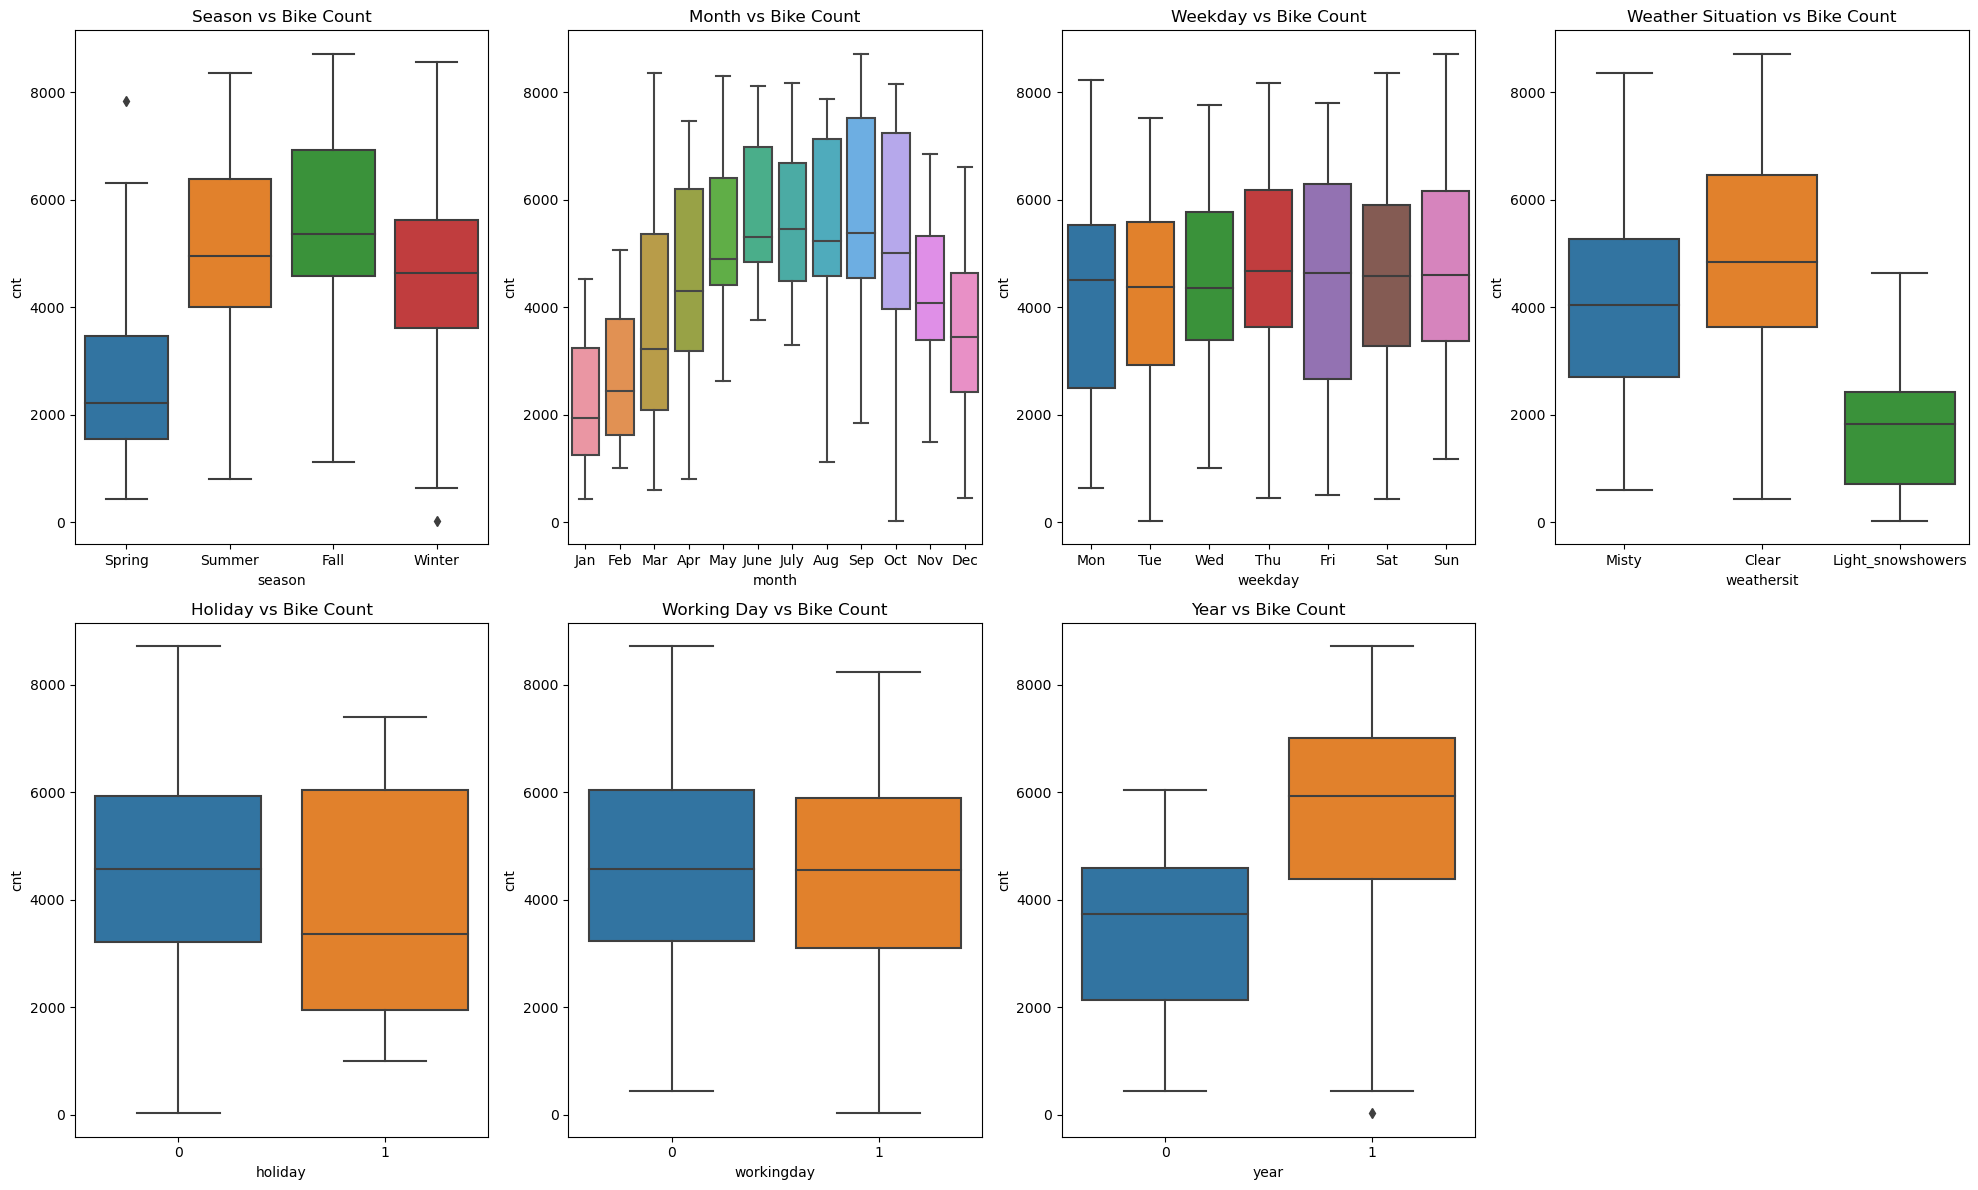

In [17]:
plt.figure(figsize=(20, 12))


plt.subplot(2, 4, 6)
sns.boxplot(x='workingday', y='cnt', data=df1)
plt.title('Working Day vs Bike Count')

plt.subplot(2, 4, 7)
sns.boxplot(x='year', y='cnt', data=df1)
plt.title('Year vs Bike Count')

plt.subplot(2, 4, 4)
sns.boxplot(x='weathersit', y='cnt', data=df1)
plt.title('Weather Situation vs Bike Count')

plt.subplot(2, 4, 1)
sns.boxplot(x='season', y='cnt', data=df1)
plt.title('Season vs Bike Count')

plt.subplot(2, 4, 2)
sns.boxplot(x='month', y='cnt', data=df1)
plt.title('Month vs Bike Count')

plt.subplot(2, 4, 5)
sns.boxplot(x='holiday', y='cnt', data=df1)
plt.title('Holiday vs Bike Count')

plt.subplot(2, 4, 3)
sns.boxplot(x='weekday', y='cnt', data=df1)
plt.title('Weekday vs Bike Count')

plt.tight_layout()

plt.show()

**Insights:**

The graphs provide a clear view of the qualitative distributions of the data. Once the model identifies the key predictors, these visualizations can help increase our confidence in the model's predictions.

- **Season:** The data reveals that the demand was highest in **Fall (Category 3)**, which has the highest median, while **Spring (Category 1)** experienced the lowest demand.
- **Year:** There was a noticeable increase in the number of users in **2019** compared to **2018**.
- **Weekday Trends:** Bike rentals appear to be evenly distributed throughout the week, with no significant peaks on any particular day.
- **Weather:** There are no rentals during heavy rain or snow, indicating that such weather conditions are unfavorable for biking. The highest rental count occurred during **Clear** and **Partly Cloudy** weather conditions.
- **Month:** Rentals peaked in **September**, and decreased in **December**, likely due to the typical heavy snowfall that month, reducing demand.
- **Holidays:** The rental count tends to be lower during **holidays**, suggesting reduced demand during these periods.
- **Working Day:** The **Workingday** boxplot shows that most bookings fall between 4000 and 6000, with the median remaining relatively constant throughout the week. This indicates that there is not much difference in bike rentals on working days versus non-working days.

In [18]:
# Function to create barplot related to categorical columns
def plot_cat_columns(column):
    plt.figure(figsize=(14, 7))
    plt.subplot(1, 2, 1)
    sns.barplot(x=column, y='cnt', data=df1)
    plt.title(f'{column} vs Bike Count')
    plt.xlabel(column)
    plt.ylabel('Bike Count')
    plt.subplot(1, 2, 2)
    sns.barplot(x=column, y='cnt', data=df, hue='year', palette='Set1')
    plt.title(f'{column} vs Bike Count by Year') 
    plt.xlabel(column)  
    plt.ylabel('Bike Count')  
    plt.legend(title='Year', labels=['2018', '2019']) 
    plt.tight_layout()
    plt.show()

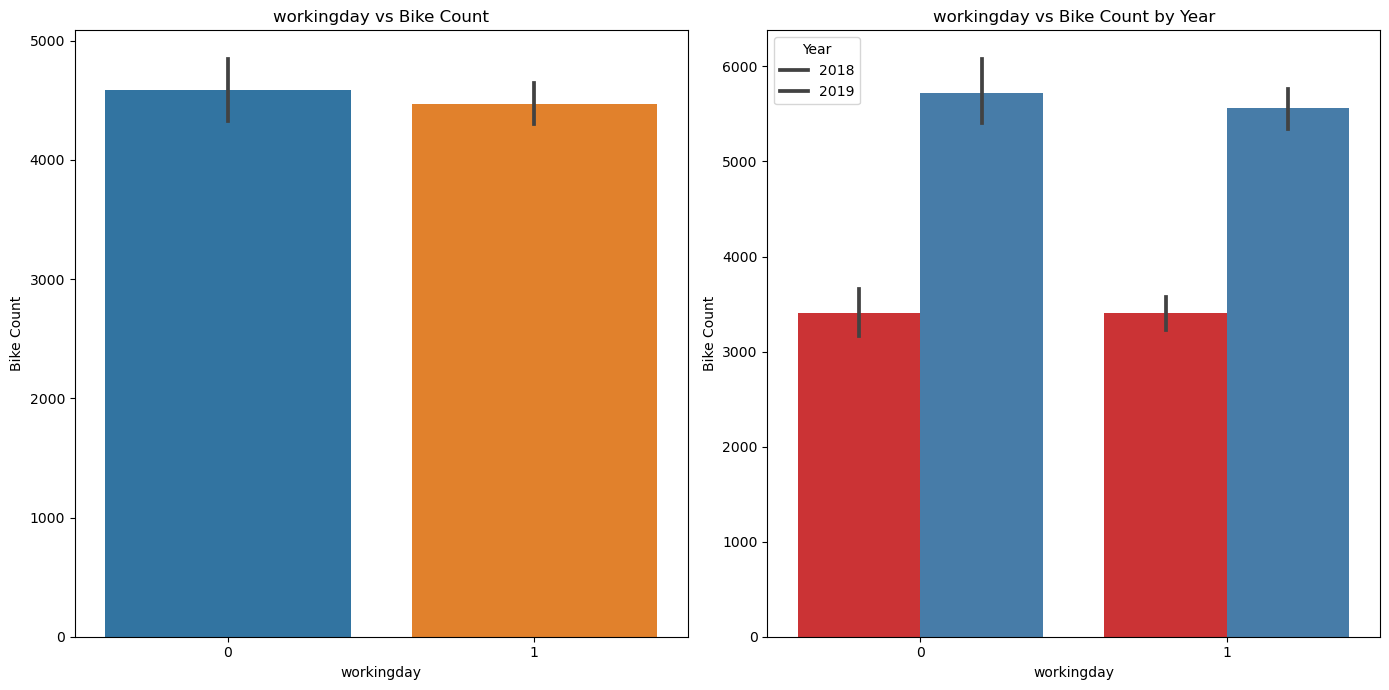

In [19]:
#Visualization for workingday column
plot_cat_columns('workingday')

### Insights 
Booking seemed to be almost equal either on working day or non-working day. But, the count increased from 2018 to 2019.

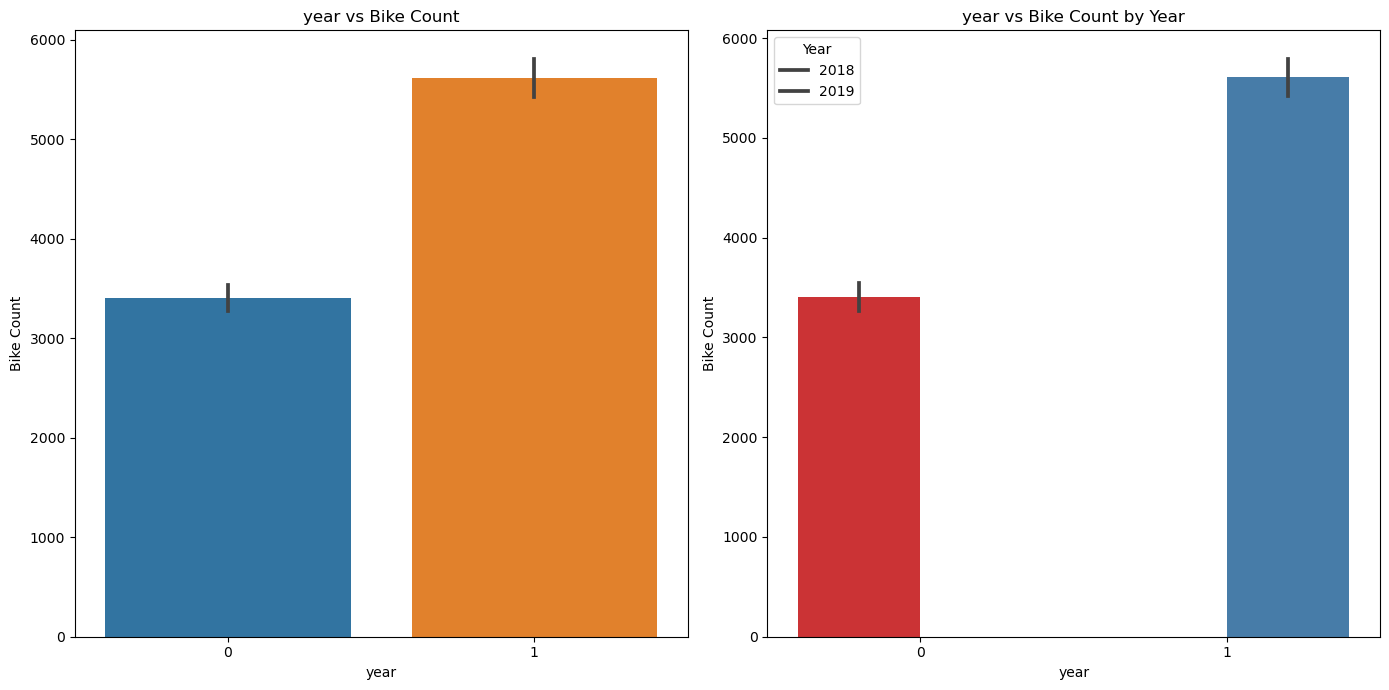

In [20]:
#Visualization for year column
plot_cat_columns('year')

### Insights 
2019 saw a higher number of bookings compared to the previous year, indicating positive growth in the business.

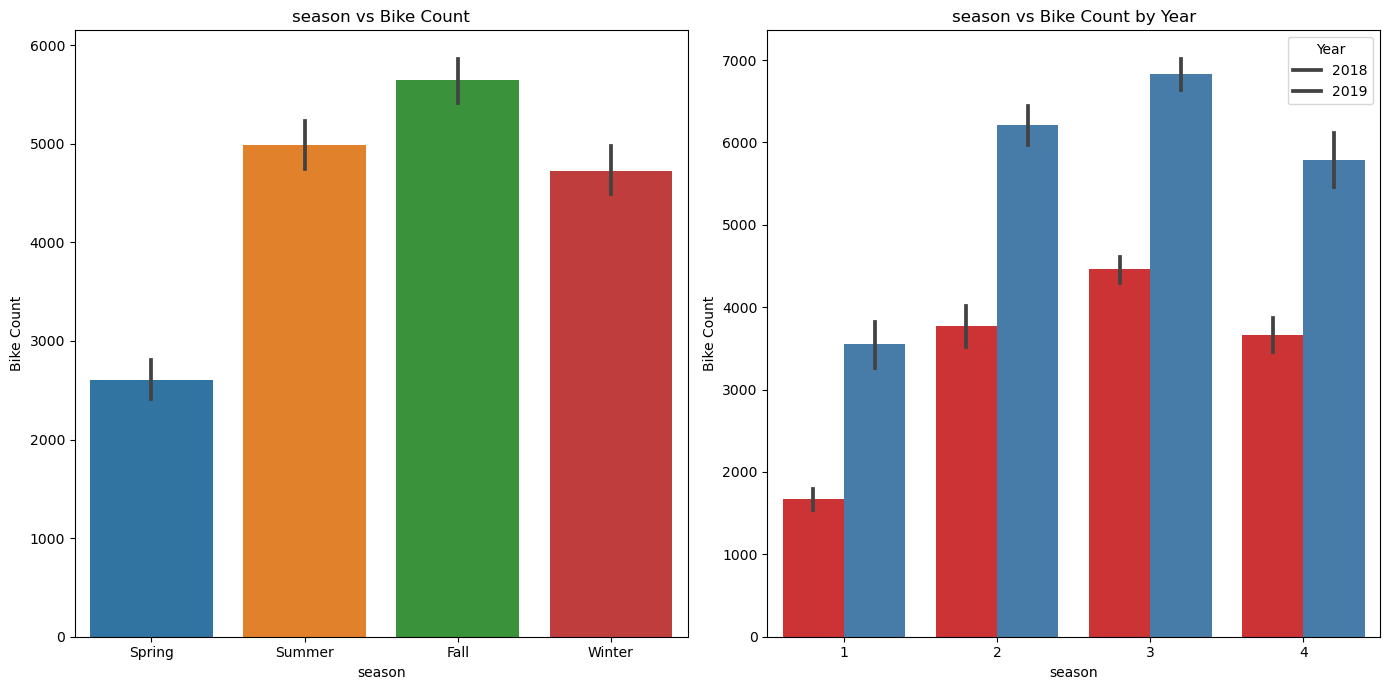

In [21]:
#visualization for season column
plot_cat_columns('season')

### Insights 
The Fall season appears to have generated the highest number of bookings. Additionally, across all seasons, the booking count showed a significant increase from 2018 to 2019.

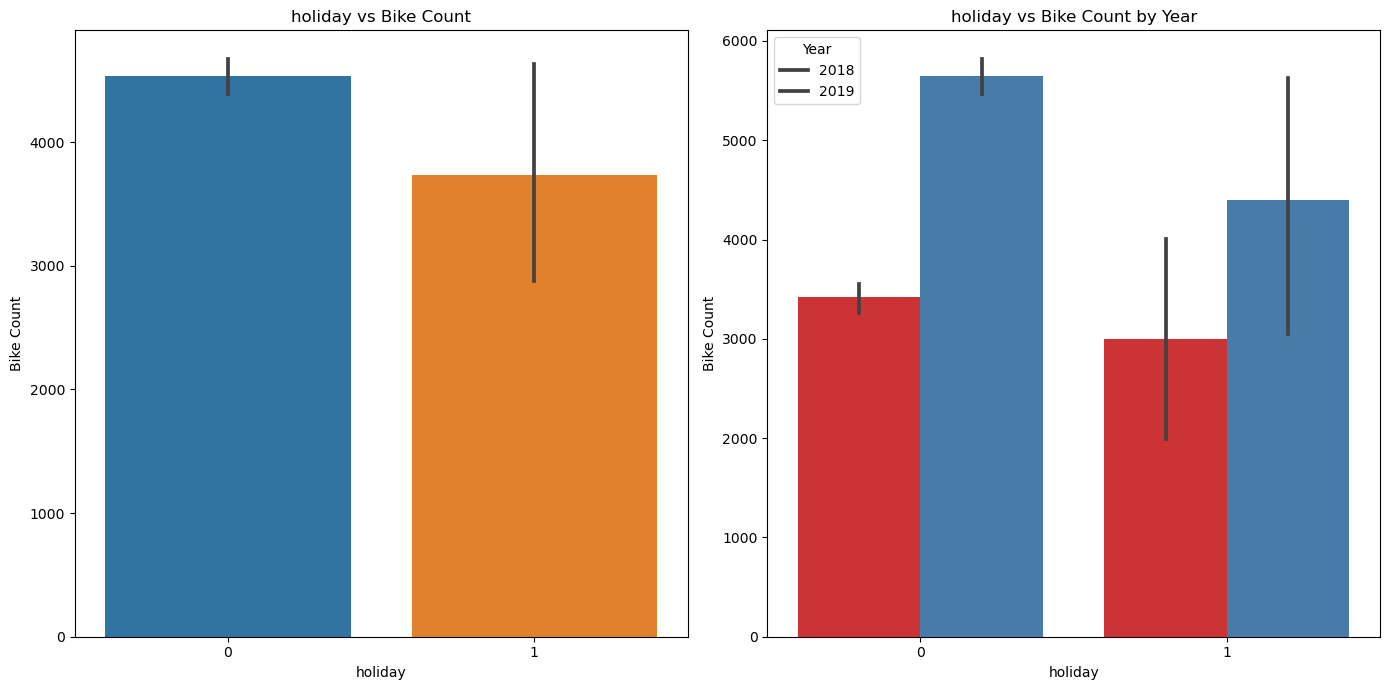

In [22]:
#Visualization for holiday column
plot_cat_columns('holiday')

### Insights 
Bookings tend to be lower on non-holidays, which makes sense as people are likely to spend time at home and enjoy with family during holidays.

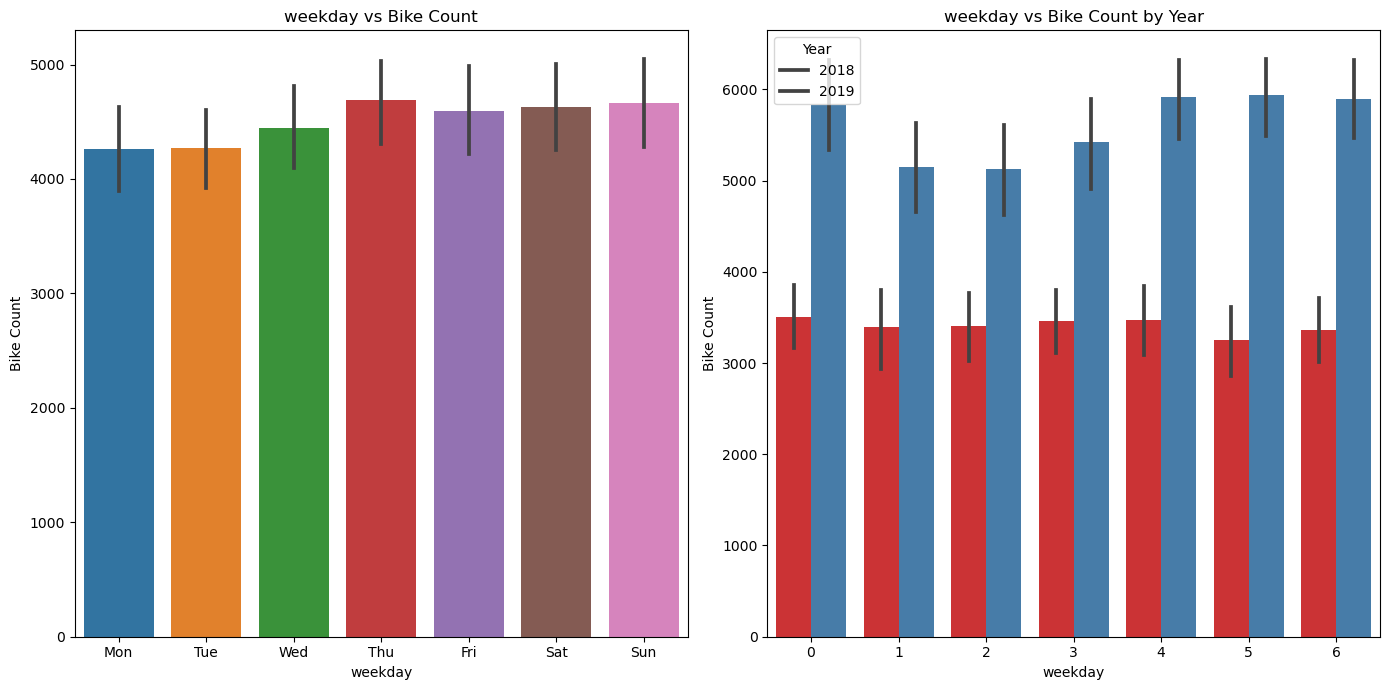

In [23]:
#Visualization for weekday column
plot_cat_columns('weekday')

### Insights 
Bookings are higher on Thursday, Friday, Saturday, and Sunday compared to the beginning of the week.

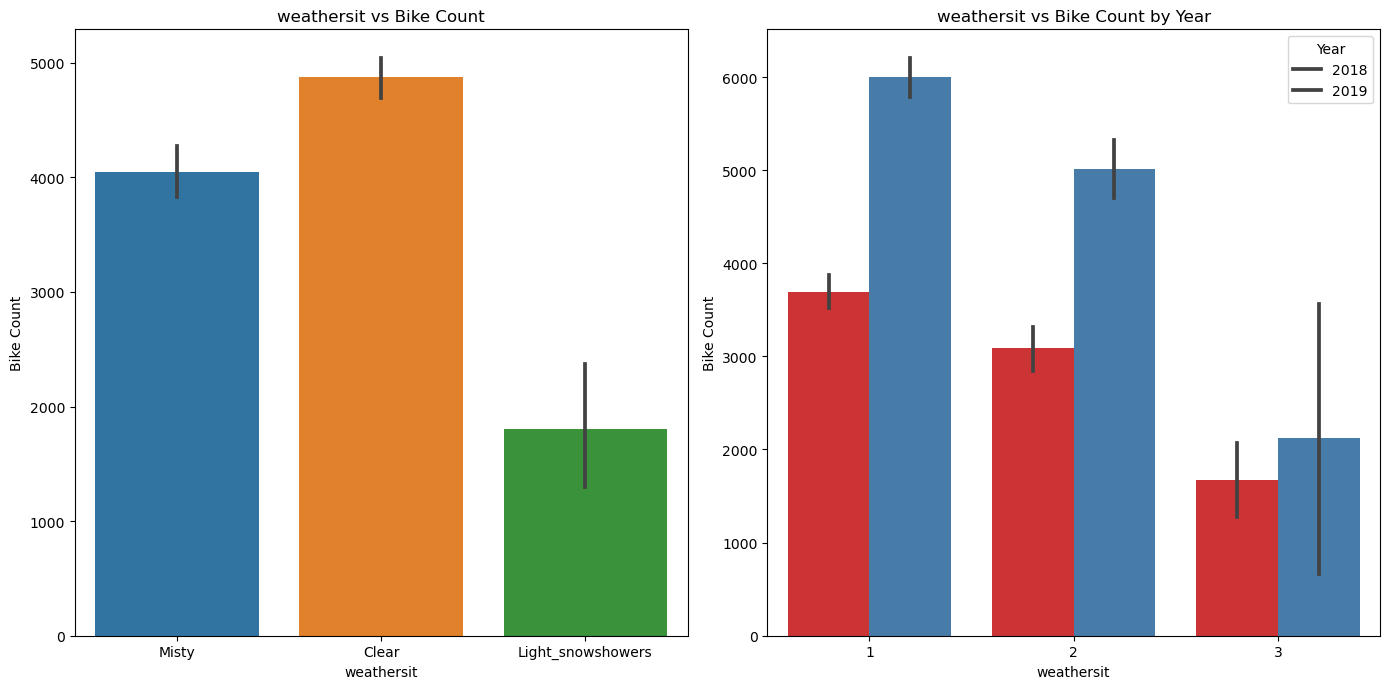

In [24]:
#Visualization for weathersit column
plot_cat_columns('weathersit')

### Insights 
Clear weather resulted in the highest number of bookings, which is expected. Moreover, compared to 2018, bookings increased across all weather conditions in 2019.

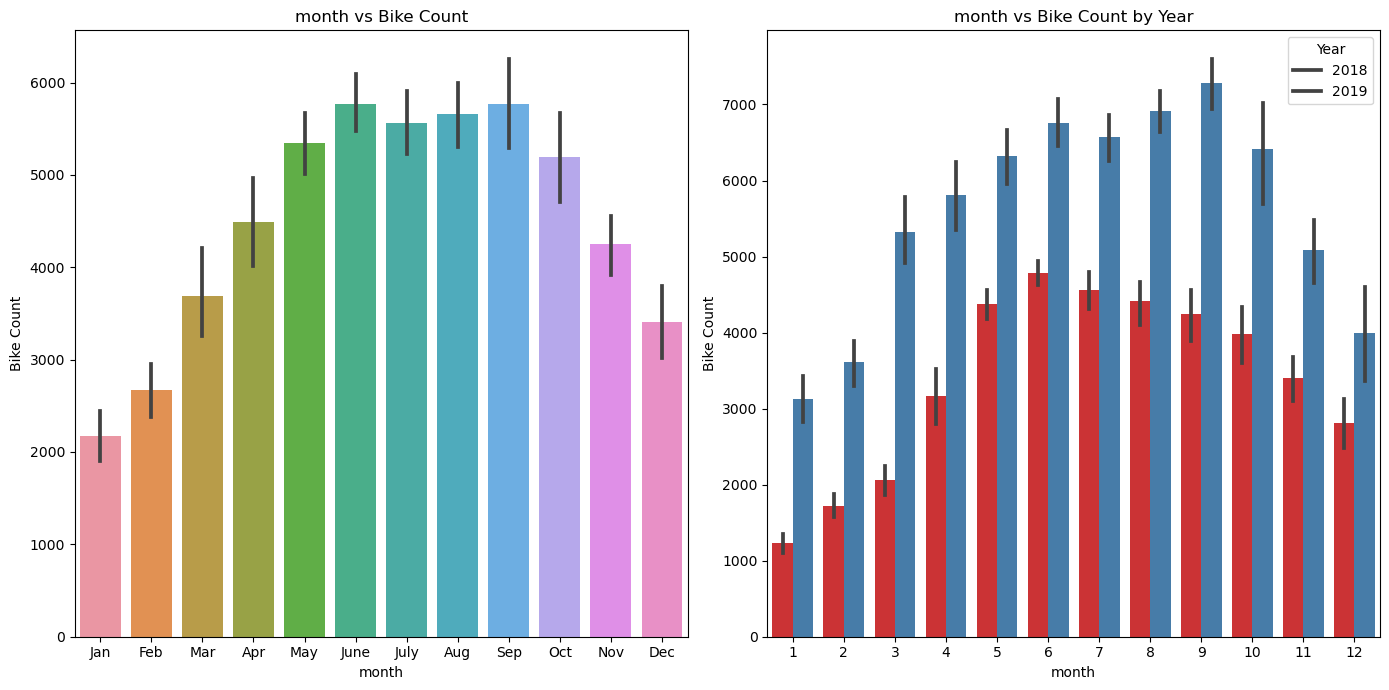

In [25]:
#Visualization for month column
plot_cat_columns('month')

### Insights 
The majority of bookings occurred during the months of May, June, July, August, September, and October. The trend shows an increase in bookings from the beginning of the year through the middle, followed by a decline as the year progressed. Additionally, the number of bookings for each month appears to have grown from 2018 to 2019.

## Analysing Numerical Features : Using a PairPlot

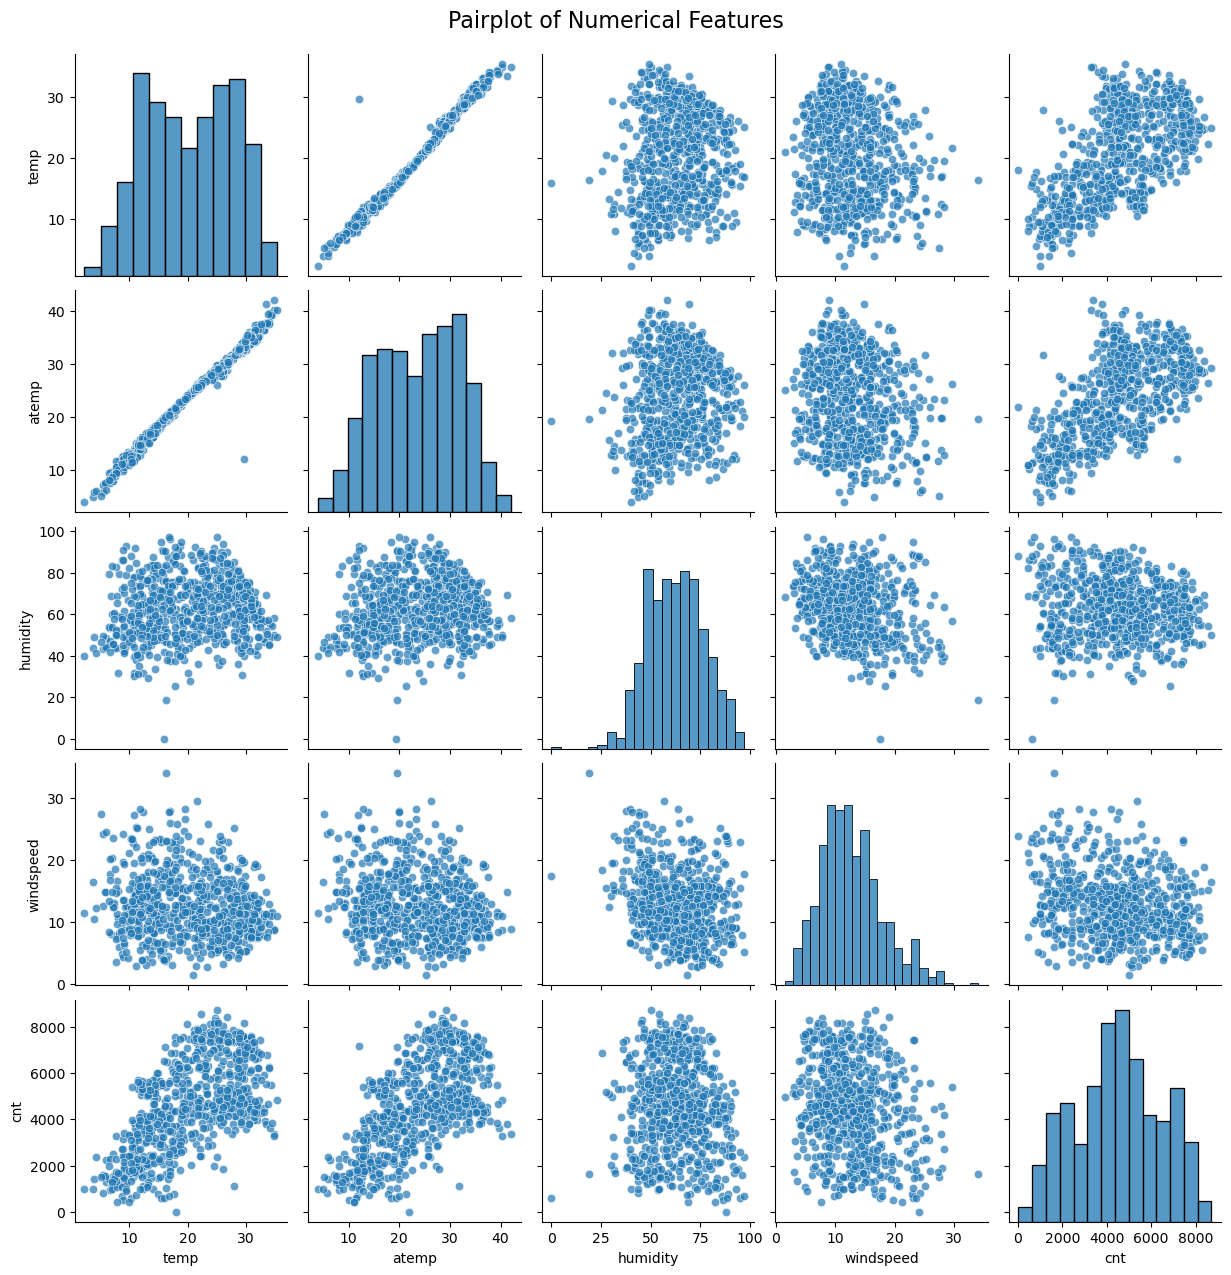

In [26]:
# Visualizing the numerical columns
sns.pairplot(data=df1, vars=['temp', 'atemp', 'humidity', 'windspeed', 'cnt'], 
             kind='scatter', palette='viridis', plot_kws={'alpha': 0.7})

plt.suptitle('Pairplot of Numerical Features', fontsize=16, y=1.02)

plt.show()

### Creating Dummy Variable
The variables **month**, **weekday**, **season**, and **weathersit** have multiple categories. For instance, **weathersit** has 3 categories, while **month** has 12. We will create dummy variables for these four categorical features: **month**, **weekday**, **season**, and **weathersit**.

In [27]:
dummy = pd.get_dummies(df1[['season', 'month', 'weekday', 'weathersit']], drop_first=True)
dummy.head()

,season_Spring,season_Summer,season_Winter,month_Aug,month_Dec,month_Feb,month_Jan,month_July,month_June,month_Mar,...,month_Oct,month_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_Light_snowshowers,weathersit_Misty
0,1,0,0,0,0,0,1,0,0,0,...,0,0,1,0,0,0,0,0,0,1
1,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1
2,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,1,0,0
3,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,1,0,0,0,0
4,1,0,0,0,0,0,1,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [28]:
# Adding the dummy variables to the original dataset
df1_new = pd.concat([df1, dummy], axis=1)
df1_new.head()

,season,year,month,holiday,weekday,workingday,weathersit,temp,atemp,humidity,...,month_Oct,month_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_Light_snowshowers,weathersit_Misty
0,Spring,0,Jan,0,Mon,1,Misty,14.110847,18.18125,80.5833,...,0,0,1,0,0,0,0,0,0,1
1,Spring,0,Jan,0,Tue,1,Misty,14.902598,17.68695,69.6087,...,0,0,0,0,0,0,1,0,0,1
2,Spring,0,Jan,0,Wed,1,Clear,8.050924,9.47025,43.7273,...,0,0,0,0,0,0,0,1,0,0
3,Spring,0,Jan,0,Thu,1,Clear,8.200000,10.60610,59.0435,...,0,0,0,0,0,1,0,0,0,0
4,Spring,0,Jan,0,Fri,1,Clear,9.305237,11.46350,43.6957,...,0,0,0,0,0,0,0,0,0,0


In [29]:
# Dropping the original columns ('season', 'weathersit', 'weekday', 'month') after creating dummy variables
df1_new.drop(['season', 'weathersit', 'weekday', 'month'], axis=1, inplace=True)
df1_new.head()

,year,holiday,workingday,temp,atemp,humidity,windspeed,cnt,season_Spring,season_Summer,...,month_Oct,month_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_Light_snowshowers,weathersit_Misty
0,0,0,1,14.110847,18.18125,80.5833,10.749882,985,1,0,...,0,0,1,0,0,0,0,0,0,1
1,0,0,1,14.902598,17.68695,69.6087,16.652113,801,1,0,...,0,0,0,0,0,0,1,0,0,1
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,...,0,0,0,0,0,0,0,0,0,0


In [30]:
df1_new.head()

,year,holiday,workingday,temp,atemp,humidity,windspeed,cnt,season_Spring,season_Summer,...,month_Oct,month_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_Light_snowshowers,weathersit_Misty
0,0,0,1,14.110847,18.18125,80.5833,10.749882,985,1,0,...,0,0,1,0,0,0,0,0,0,1
1,0,0,1,14.902598,17.68695,69.6087,16.652113,801,1,0,...,0,0,0,0,0,0,1,0,0,1
2,0,0,1,8.050924,9.47025,43.7273,16.636703,1349,1,0,...,0,0,0,0,0,0,0,1,0,0
3,0,0,1,8.200000,10.60610,59.0435,10.739832,1562,1,0,...,0,0,0,0,0,1,0,0,0,0
4,0,0,1,9.305237,11.46350,43.6957,12.522300,1600,1,0,...,0,0,0,0,0,0,0,0,0,0


In [31]:
df1_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 730 entries, 0 to 729
Data columns (total 30 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   year                          730 non-null    int64  
 1   holiday                       730 non-null    int64  
 2   workingday                    730 non-null    int64  
 3   temp                          730 non-null    float64
 4   atemp                         730 non-null    float64
 5   humidity                      730 non-null    float64
 6   windspeed                     730 non-null    float64
 7   cnt                           730 non-null    int64  
 8   season_Spring                 730 non-null    uint8  
 9   season_Summer                 730 non-null    uint8  
 10  season_Winter                 730 non-null    uint8  
 11  month_Aug                     730 non-null    uint8  
 12  month_Dec                     730 non-null    uint8  
 13  month

## Step 4: Splitting the Data into Training and Testing Sets

In [32]:
from sklearn.model_selection import train_test_split
import numpy as np

np.random.seed(0)
df1_train, df1_test = train_test_split(df1_new, train_size=0.7, random_state=100)

print(f"Train set shape: {df1_train.shape}")
print(f"Test set shape: {df1_test.shape}")

Train set shape: (510, 30)
Test set shape: (220, 30)


## Step 6 : **Rescaling the Features**

Although scaling does not have a significant impact on simple linear regression, it plays a crucial role in multiple linear regression models. In our dataset, the target variable `cnt` has much higher values compared to other features like `temp`, `atemp`, and so on. Therefore, it's essential to rescale the features to ensure they are on a comparable scale. If the scales are not comparable, the coefficients obtained from fitting the regression model may vary significantly, which could lead to inaccurate or misleading results during model evaluation.

Rescaling ensures that all the coefficients are measured on the same scale, making the model easier to interpret and evaluate. There are two commonly used methods for rescaling:

1. **Min-Max Scaling**
2. **Standardization (Mean = 0, Standard Deviation = 1)**

In this case, we will apply **Min-Max scaling**, which transforms the data into a specified range, typically [0, 1], to ensure all features contribute equally to the model.

In [33]:
from sklearn.preprocessing import MinMaxScaler

# Applying MinMaxScaler to the numerical columns
scaler = MinMaxScaler()

# List of numerical variables to be rescaled
numerical_varibles = ['temp', 'atemp', 'humidity', 'windspeed', 'cnt']

# Rescaling the features in the training set
df1_train[numerical_varibles] = scaler.fit_transform(df1_train[numerical_varibles])

df1_train.head()

,year,holiday,workingday,temp,atemp,humidity,windspeed,cnt,season_Spring,season_Summer,...,month_Oct,month_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_Light_snowshowers,weathersit_Misty
576,1,0,1,0.815169,0.766351,0.725633,0.264686,0.827658,0,0,...,0,0,0,0,0,0,0,1,0,0
426,1,0,0,0.442393,0.438975,0.640189,0.255342,0.465255,1,0,...,0,0,0,0,1,0,0,0,0,1
728,1,0,1,0.245101,0.200348,0.498067,0.663106,0.204096,1,0,...,0,0,1,0,0,0,0,0,0,0
482,1,0,0,0.395666,0.391735,0.504508,0.188475,0.482973,0,1,...,0,0,0,0,1,0,0,0,0,1
111,0,0,0,0.345824,0.318819,0.751824,0.380981,0.191095,0,1,...,0,0,0,0,1,0,0,0,0,1


In [34]:
df1_train.describe()

,year,holiday,workingday,temp,atemp,humidity,windspeed,cnt,season_Spring,season_Summer,...,month_Oct,month_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_Light_snowshowers,weathersit_Misty
count,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,...,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000,510.000000
mean,0.507843,0.025490,0.711765,0.537440,0.513156,0.650480,0.320883,0.513499,0.243137,0.247059,...,0.084314,0.080392,0.154902,0.129412,0.137255,0.143137,0.152941,0.135294,0.029412,0.345098
std,0.500429,0.157763,0.453386,0.225858,0.212410,0.145846,0.169803,0.224421,0.429398,0.431725,...,0.278131,0.272166,0.362166,0.335985,0.344454,0.350557,0.360284,0.342373,0.169124,0.475867
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.339853,0.332086,0.538643,0.199179,0.356420,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1.000000,0.000000,1.000000,0.542596,0.529718,0.653714,0.296763,0.518638,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,1.000000,0.735215,0.688457,0.754830,0.414447,0.684710,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


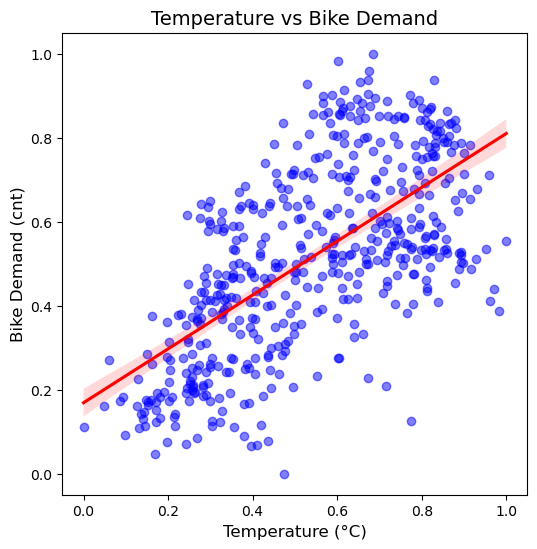

In [35]:
# Creating a regression plot to visualize the relationship between 'temp' and 'cnt'
plt.figure(figsize=[6,6])
sns.regplot(x='temp', y='cnt', data=df1_train, scatter_kws={'color': 'blue', 'alpha': 0.5}, line_kws={'color': 'red'})

plt.title('Temperature vs Bike Demand', fontsize=14)
plt.xlabel('Temperature (°C)', fontsize=12)
plt.ylabel('Bike Demand (cnt)', fontsize=12)

plt.show()


## Insights 
"The visualization clearly confirms the positive correlation between temperature (temp) and bike demand (cnt), indicating that as the temperature increases, the demand for bikes also tends to rise."

This insight aligns with the understanding that warmer weather generally encourages more bike rentals.

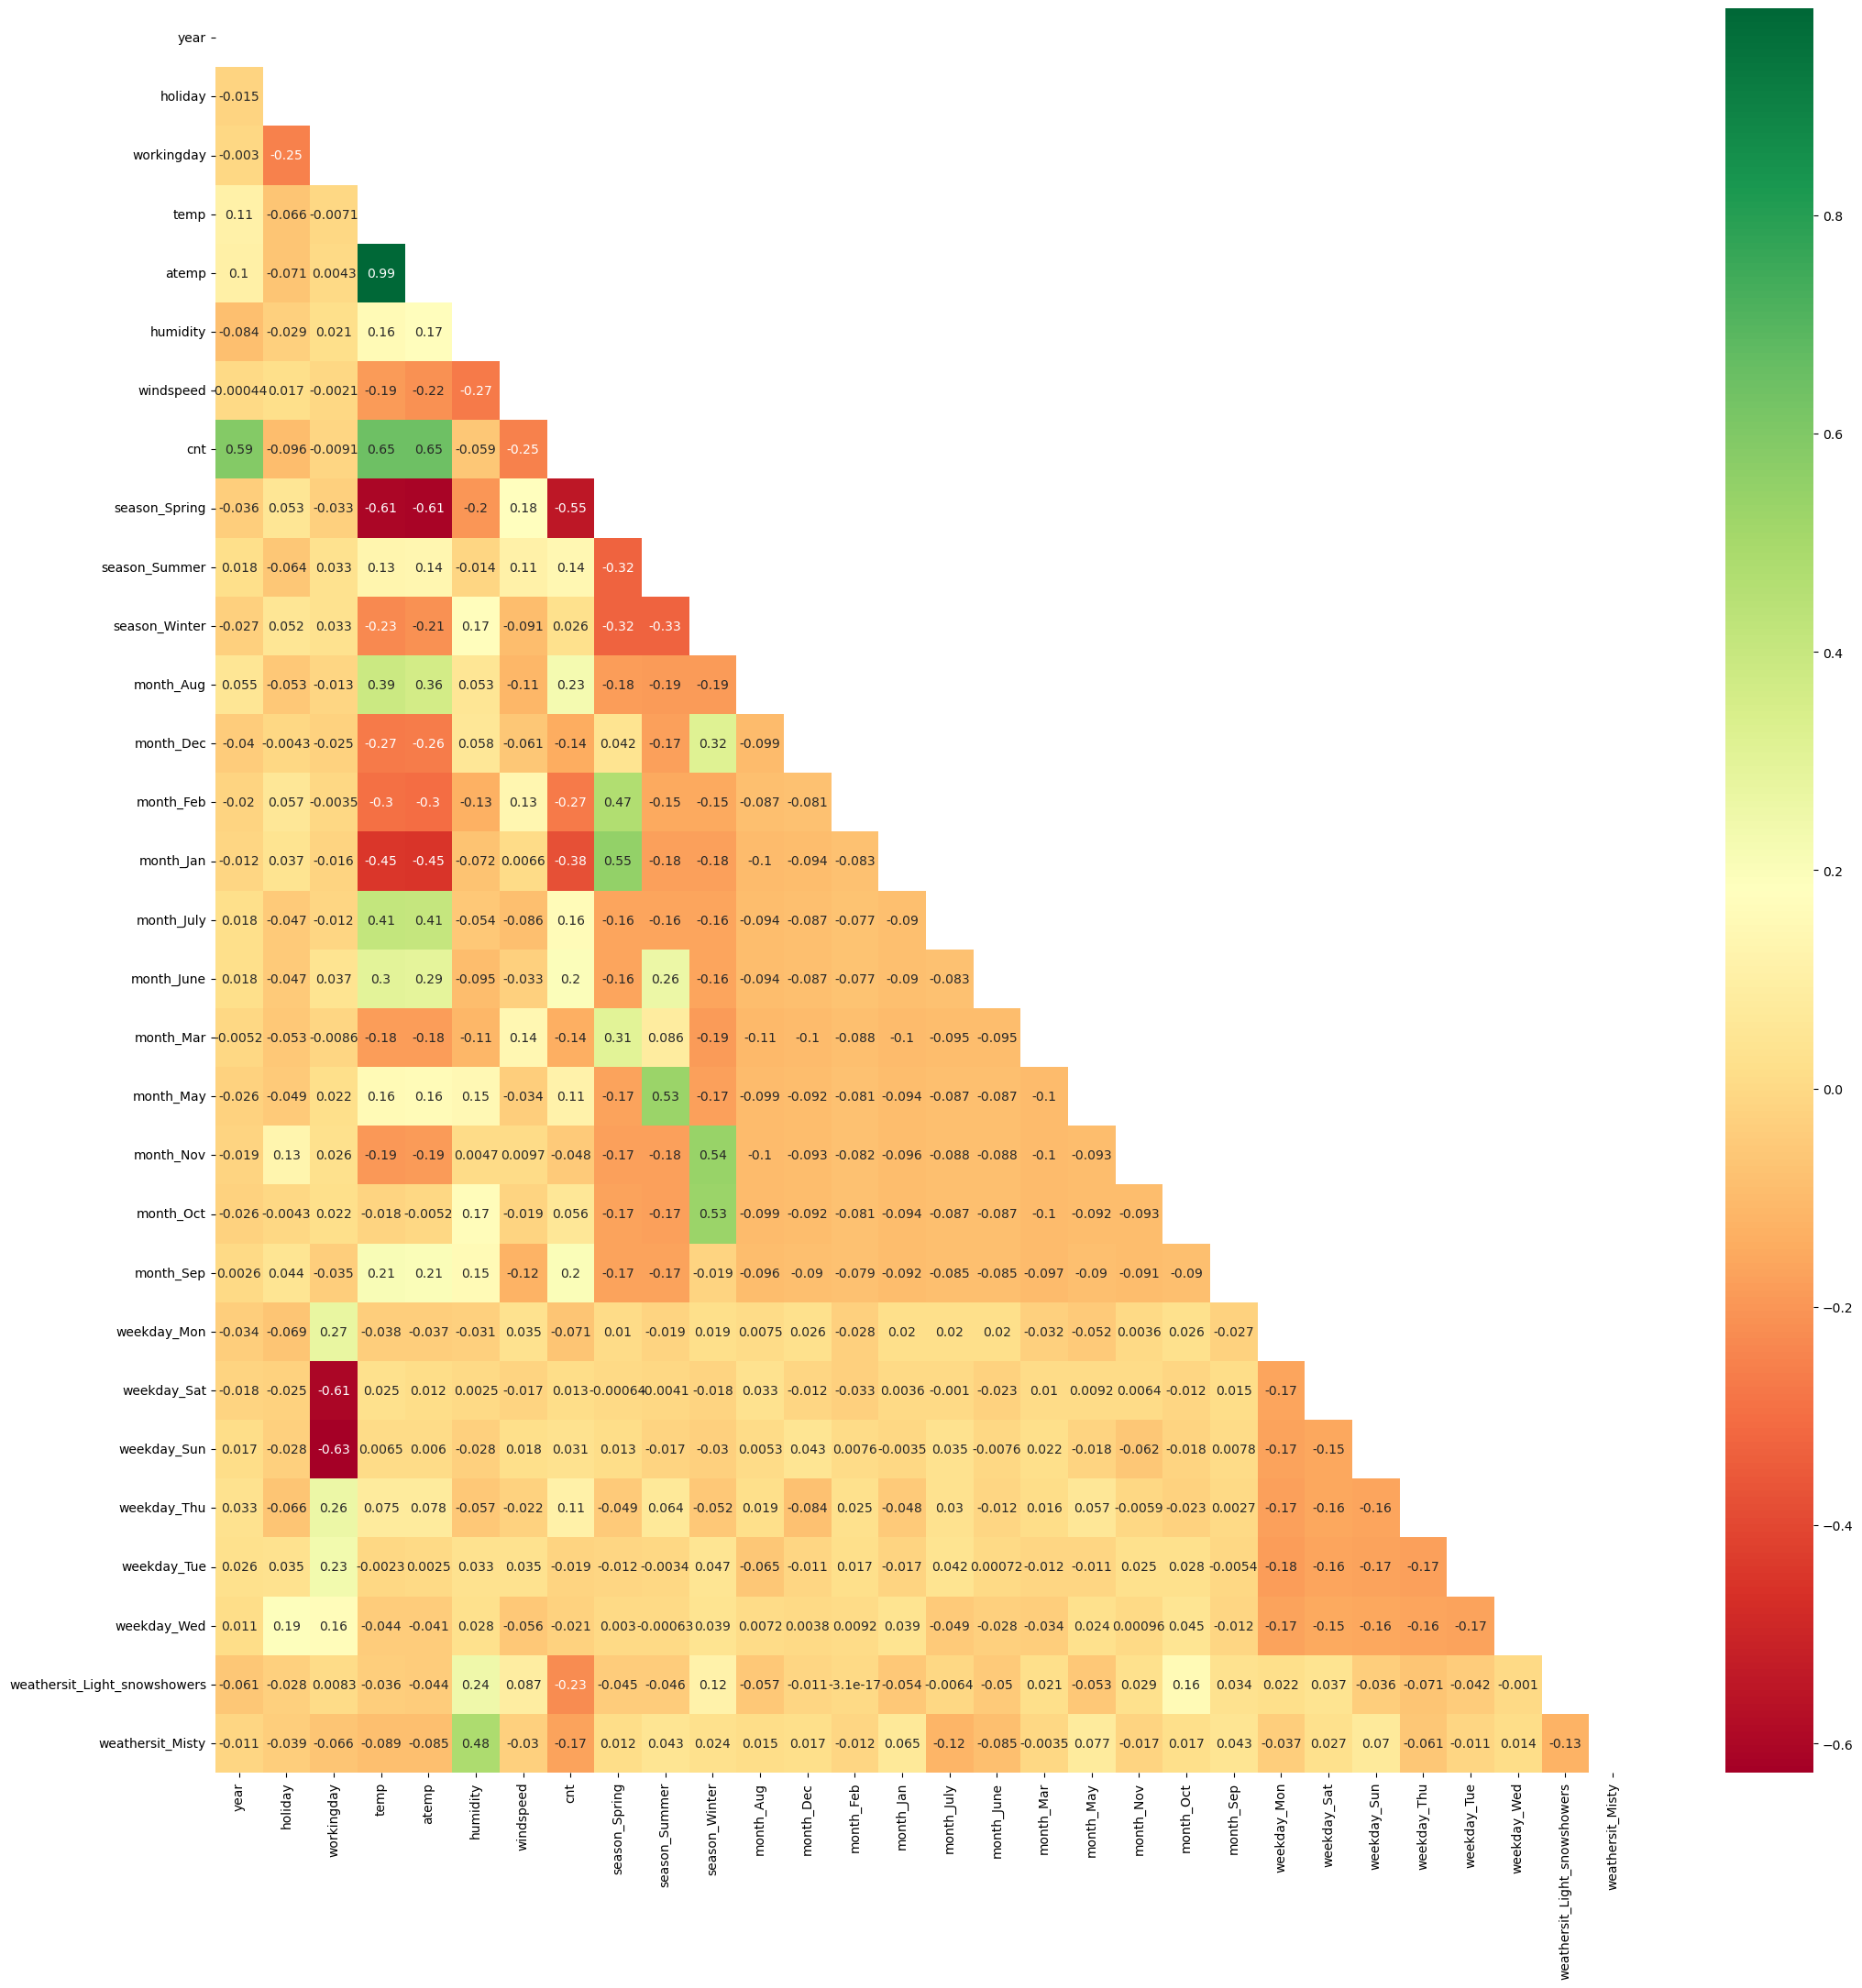

In [36]:
# Creating a correlation matrix and masking the upper triangle to avoid redundancy
plt.figure(figsize = (25, 25))
matrix = np.triu(df1_train.corr())

sns.heatmap(df1_train.corr(), annot=True, cmap="RdYlGn", mask=matrix)
plt.show()

## Insights 

- The variable `cnt` shows strong correlations with the `year` and `temp` variables, indicating that the demand for bikes (`cnt`) is influenced by the year and temperature.
- The `Misty` weather condition appears to be correlated with `humidity`, suggesting that higher humidity levels tend to coincide with misty weather.
- The `Spring` season has a notable correlation with the months of January and February, implying that spring-like conditions may begin to emerge around these months.
- The `Summer` season exhibits a significant correlation with May, suggesting that the bike demand is highest in this month during the summer.
- The `Winter` season shows a good correlation with the months of October and November, indicating that these months experience winter-like conditions, influencing bike rentals.

These correlations can help understand how different factors and seasons impact the demand for bikes and guide the development of a more accurate predictive model.

In [37]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor
import pandas as pd

# Splitting the target variable 'cnt' and the features (independent variables)
y_train = df1_train.pop('cnt')
X_train = df1_train

# Initializing the Linear Regression model
lm = LinearRegression()

# Performing Recursive Feature Elimination (RFE) to select the top 15 features
rfe = RFE(lm, n_features_to_select=15) 
rfe = rfe.fit(X_train, y_train)

print("Selected variables via RFE:")
print(list(zip(X_train.columns, rfe.support_, rfe.ranking_)))

col = X_train.columns[rfe.support_]

rejected_cols = X_train.columns[~rfe.support_]
print("Rejected columns:", rejected_cols)

def calculateVIF(df):
    vif = pd.DataFrame()
    vif['Features'] = df.columns
    vif['VIF'] = [variance_inflation_factor(df.values, i) for i in range(df.shape[1])]
    vif['VIF'] = round(vif['VIF'], 2)
    vif = vif.sort_values(by="VIF", ascending=False)
    return vif

X_train_rfe = X_train[col]

vif_result = calculateVIF(X_train_rfe)

print("\nVIF for RFE-selected features:")
print(vif_result)

print("\nColumns selected after RFE:", col)

Selected variables via RFE:
[('year', True, 1), ('holiday', True, 1), ('workingday', False, 4), ('temp', True, 1), ('atemp', False, 3), ('humidity', True, 1), ('windspeed', True, 1), ('season_Spring', True, 1), ('season_Summer', True, 1), ('season_Winter', True, 1), ('month_Aug', False, 10), ('month_Dec', True, 1), ('month_Feb', False, 2), ('month_Jan', True, 1), ('month_July', True, 1), ('month_June', False, 12), ('month_Mar', False, 15), ('month_May', False, 9), ('month_Nov', True, 1), ('month_Oct', False, 13), ('month_Sep', True, 1), ('weekday_Mon', False, 8), ('weekday_Sat', False, 5), ('weekday_Sun', False, 6), ('weekday_Thu', False, 14), ('weekday_Tue', False, 7), ('weekday_Wed', False, 11), ('weathersit_Light_snowshowers', True, 1), ('weathersit_Misty', True, 1)]
Rejected columns: Index(['workingday', 'atemp', 'month_Aug', 'month_Feb', 'month_June',
       'month_Mar', 'month_May', 'month_Oct', 'weekday_Mon', 'weekday_Sat',
       'weekday_Sun', 'weekday_Thu', 'weekday_Tue', 'we

## Step 5 Building a linear Model

## Constant Variable  
In statsmodels, it is essential to explicitly include a constant term using `sm.add_constant(X)`. Without this step, statsmodels defaults to fitting a regression line that passes through the origin.

In [38]:
import statsmodels.api as sm

X_train_with_constant = sm.add_constant(X_train_rfe)

# Building and fitting the OLS regression model
linear_model_1 = sm.OLS(y_train, X_train_with_constant).fit()

print("Summary of the First Linear Regression Model:")
print(linear_model_1.summary())

Summary of the First Linear Regression Model:
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.845
Model:                            OLS   Adj. R-squared:                  0.840
Method:                 Least Squares   F-statistic:                     179.4
Date:                Tue, 03 Dec 2024   Prob (F-statistic):          8.15e-189
Time:                        20:03:17   Log-Likelihood:                 514.19
No. Observations:                 510   AIC:                            -996.4
Df Residuals:                     494   BIC:                            -928.6
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------

### Insights
VIF value must be less than ≤ 5. Indicates low multicollinearity. The independent variable is reasonably independent of other predictors in the model.So we will drop humidity with high VIF.

In [39]:
# Dropping the 'humidity' variable due to high VIF values
X_train_updated = X_train_rfe.drop(['humidity'], axis=1)

vif_updated = calculateVIF(X_train_updated)

print("Updated VIF values after dropping 'humidity':")
print(vif_updated)

Updated VIF values after dropping 'humidity':
                        Features   VIF
2                           temp  5.17
3                      windspeed  4.67
6                  season_Winter  2.95
4                  season_Spring  2.89
5                  season_Summer  2.24
0                           year  2.07
10                     month_Nov  1.81
8                      month_Jan  1.66
9                     month_July  1.59
13              weathersit_Misty  1.57
7                      month_Dec  1.47
11                     month_Sep  1.35
12  weathersit_Light_snowshowers  1.09
1                        holiday  1.06


In [40]:
# Building the second linear regression model after dropping 'humidity'
X_train_lm_2 = sm.add_constant(X_train_updated)
lr_2 = sm.OLS(y_train, X_train_lm_2).fit() 

print("Summary of the second linear regression model:")
print(lr_2.summary())

Summary of the second linear regression model:
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.839
Model:                            OLS   Adj. R-squared:                  0.835
Method:                 Least Squares   F-statistic:                     184.5
Date:                Tue, 03 Dec 2024   Prob (F-statistic):          4.75e-186
Time:                        20:03:17   Log-Likelihood:                 504.85
No. Observations:                 510   AIC:                            -979.7
Df Residuals:                     495   BIC:                            -916.2
Df Model:                          14                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------

In [41]:
# Dropping the variable 'nov' due to its high p-value
X_train_updated = X_train_updated.drop(['month_Nov'], axis=1)

vif_updated = calculateVIF(X_train_updated)

print("Updated VIF after dropping 'Nov':")
print(vif_updated)

Updated VIF after dropping 'Nov':
                        Features   VIF
2                           temp  5.14
3                      windspeed  4.62
4                  season_Spring  2.89
5                  season_Summer  2.24
0                           year  2.07
6                  season_Winter  2.05
8                      month_Jan  1.65
9                     month_July  1.59
12              weathersit_Misty  1.57
10                     month_Sep  1.34
7                      month_Dec  1.29
11  weathersit_Light_snowshowers  1.08
1                        holiday  1.04


## Insights
Dropping a few variables hasn't significantly impacted the VIF values. Let's continue refining the model to achieve better results.



In [42]:
# Building the third linear regression model
X_train_lm_3 = sm.add_constant(X_train_updated)
lr_3 = sm.OLS(y_train, X_train_lm_3).fit()
print("Summary of the 3rd Linear Regression Model:")
print(lr_3.summary())

Summary of the 3rd Linear Regression Model:
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.838
Model:                            OLS   Adj. R-squared:                  0.834
Method:                 Least Squares   F-statistic:                     197.0
Date:                Tue, 03 Dec 2024   Prob (F-statistic):          2.74e-186
Time:                        20:03:17   Log-Likelihood:                 502.67
No. Observations:                 510   AIC:                            -977.3
Df Residuals:                     496   BIC:                            -918.1
Df Model:                          13                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [43]:
# We can drop dec variable as it has high p-value
X_train_updated = X_train_updated.drop(['month_Dec'], axis = 1)

vif_updated = calculateVIF(X_train_updated)

print("Updated VIF after dropping 'Dec':")
print(vif_updated)

Updated VIF after dropping 'Dec':
                        Features   VIF
2                           temp  5.13
3                      windspeed  4.62
4                  season_Spring  2.75
5                  season_Summer  2.24
0                           year  2.07
6                  season_Winter  1.78
7                      month_Jan  1.61
8                     month_July  1.59
11              weathersit_Misty  1.56
9                      month_Sep  1.34
10  weathersit_Light_snowshowers  1.08
1                        holiday  1.04


In [44]:
# Building the fourth linear regression model
X_train_lm_4 = sm.add_constant(X_train_updated)
lr_4 = sm.OLS(y_train, X_train_lm_4).fit()
print("Summary of the 4th Linear Regression Model:")
print(lr_4.summary())

Summary of the 4th Linear Regression Model:
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.837
Model:                            OLS   Adj. R-squared:                  0.833
Method:                 Least Squares   F-statistic:                     212.3
Date:                Tue, 03 Dec 2024   Prob (F-statistic):          8.14e-187
Time:                        20:03:17   Log-Likelihood:                 501.13
No. Observations:                 510   AIC:                            -976.3
Df Residuals:                     497   BIC:                            -921.2
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [45]:
# Dropping the 'jan' variable due to its high p-value
X_train_updated = X_train_updated.drop(['month_Jan'], axis = 1)

vif_updated = calculateVIF(X_train_updated)

# Printing the updated VIF values
print("Updated VIF after dropping 'Jan':")
print(vif_updated)

Updated VIF after dropping 'Jan':
                        Features   VIF
2                           temp  5.09
3                      windspeed  4.60
5                  season_Summer  2.23
4                  season_Spring  2.08
0                           year  2.07
6                  season_Winter  1.78
7                     month_July  1.58
10              weathersit_Misty  1.55
8                      month_Sep  1.34
9   weathersit_Light_snowshowers  1.08
1                        holiday  1.04


In [46]:
# Building 5th linear regression model

X_train_lm_5 = sm.add_constant(X_train_updated)
lr_5 = sm.OLS(y_train,X_train_lm_5).fit()
print("Summary of the 5th Linear Regression Model:")
print(lr_5.summary())

Summary of the 5th Linear Regression Model:
                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.835
Model:                            OLS   Adj. R-squared:                  0.832
Method:                 Least Squares   F-statistic:                     229.6
Date:                Tue, 03 Dec 2024   Prob (F-statistic):          5.06e-187
Time:                        20:03:17   Log-Likelihood:                 498.80
No. Observations:                 510   AIC:                            -973.6
Df Residuals:                     498   BIC:                            -922.8
Df Model:                          11                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------

In [47]:
# Dropping 'month_July' variable as it has a high p-value
X_train_updated = X_train_updated.drop(['month_July'], axis = 1)

vif_updated = calculateVIF(X_train_updated)

print("Updated VIF after dropping 'month_July':")
print(vif_updated)

Updated VIF after dropping 'month_July':
                       Features   VIF
3                     windspeed  4.60
2                          temp  3.84
0                          year  2.07
4                 season_Spring  1.99
5                 season_Summer  1.90
6                 season_Winter  1.63
9              weathersit_Misty  1.55
7                     month_Sep  1.23
8  weathersit_Light_snowshowers  1.08
1                       holiday  1.04


In [48]:
# Building 6th linear regression model

X_train_lm_6 = sm.add_constant(X_train_updated)
lr_6 = sm.OLS(y_train, X_train_lm_6).fit()

print(lr_6.summary())

                            OLS Regression Results                            
Dep. Variable:                    cnt   R-squared:                       0.833
Model:                            OLS   Adj. R-squared:                  0.829
Method:                 Least Squares   F-statistic:                     248.4
Date:                Tue, 03 Dec 2024   Prob (F-statistic):          1.47e-186
Time:                        20:03:17   Log-Likelihood:                 494.84
No. Observations:                 510   AIC:                            -967.7
Df Residuals:                     499   BIC:                            -921.1
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                   coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const           

The model lr_6 appears to be a strong candidate, as it exhibits minimal multicollinearity among the predictors, with all predictor p-values being statistically significant. The F-statistic of 248.4, which is well above 1, coupled with an extremely low p-value of 1.47e-186, suggests that the model is highly reliable and provides a statistically significant explanation of the variation in the target variable.

In [49]:
# Checking the parameters and their coefficient values
lr_6.params

const                           0.190855
year                            0.234132
holiday                        -0.096316
temp                            0.477737
windspeed                      -0.148098
season_Spring                  -0.055406
season_Summer                   0.062076
season_Winter                   0.094476
month_Sep                       0.090998
weathersit_Light_snowshowers   -0.285031
weathersit_Misty               -0.078741
dtype: float64

## Step 6: Residual Analysis of the train data and validation

In [50]:
X_train_lm_6

,const,year,holiday,temp,windspeed,season_Spring,season_Summer,season_Winter,month_Sep,weathersit_Light_snowshowers,weathersit_Misty
576,1.0,1,0,0.815169,0.264686,0,0,0,0,0,0
426,1.0,1,0,0.442393,0.255342,1,0,0,0,0,1
728,1.0,1,0,0.245101,0.663106,1,0,0,0,0,0
482,1.0,1,0,0.395666,0.188475,0,1,0,0,0,1
111,1.0,0,0,0.345824,0.380981,0,1,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...
578,1.0,1,0,0.863973,0.187140,0,0,0,0,0,0
53,1.0,0,0,0.202618,0.111379,1,0,0,0,0,0
350,1.0,0,0,0.248216,0.431816,0,0,1,0,0,1
79,1.0,0,0,0.462664,0.529881,0,1,0,0,0,1


In [51]:
#let's predict the y_train 
y_train_prediction = lr_6.predict(X_train_lm_6)

To verify whether the error terms follow a normal distribution, which is a key assumption in linear regression, we can plot the histogram of the residuals. This will help us assess the distribution of the error terms and determine if they approximate normality.

### Normality of error terms 

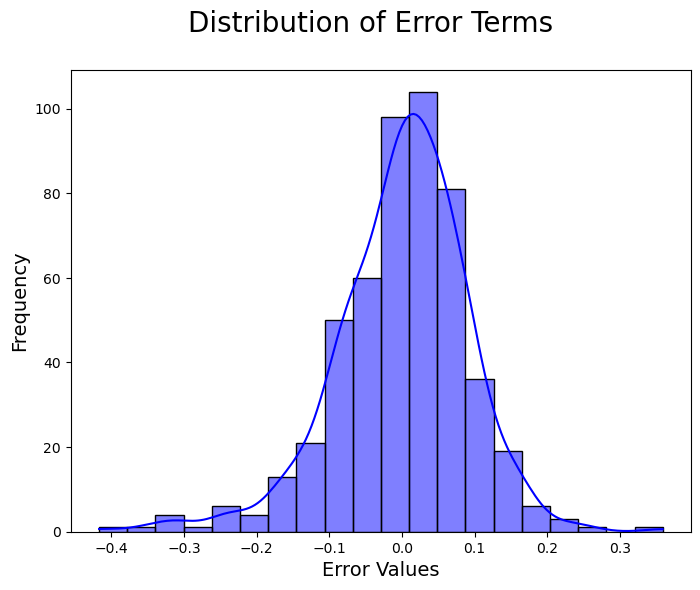

In [52]:
# Plot the histogram of the error terms

fig = plt.figure(figsize=(8, 6))
sns.histplot((y_train - y_train_prediction), bins=20, kde=True, color='blue')
fig.suptitle('Distribution of Error Terms', fontsize=20) 
plt.xlabel('Error Values', fontsize=14)
plt.ylabel('Frequency', fontsize=14)
plt.show()

### Insights
The distribution of error terms is symmetric around zero, indicating a normal distribution, which supports the assumptions of linear regression.

The Q-Q plot compares the quantiles of the error terms with the quantiles of a normal distribution. If the points follow a straight line, it indicates that the error terms are normally distributed.

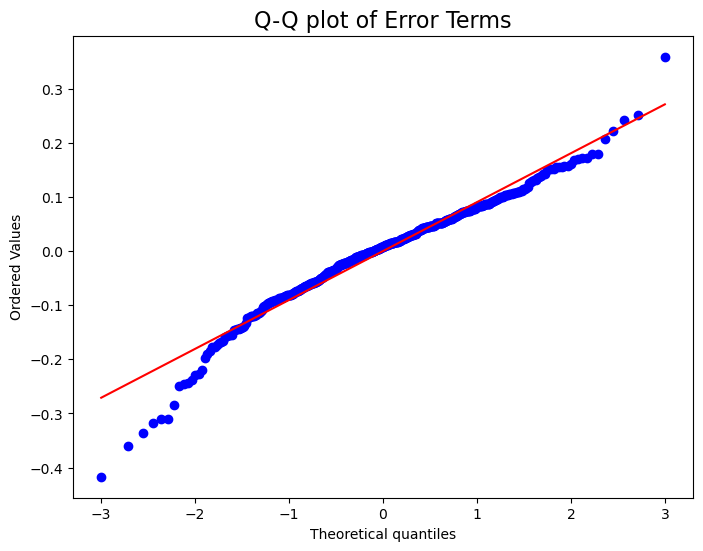

In [53]:
import scipy.stats as stats

# Q-Q plot to check if the error terms follow a normal distribution
plt.figure(figsize=(8,6))
stats.probplot(y_train - y_train_prediction, dist="norm", plot=plt)
plt.title('Q-Q plot of Error Terms', fontsize=16)
plt.show()

### Insights:  
The majority of the data points align closely with the straight line, suggesting that the error terms follow a normal distribution.

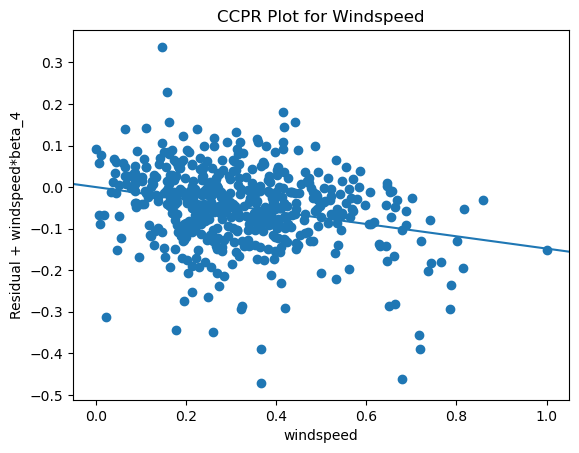

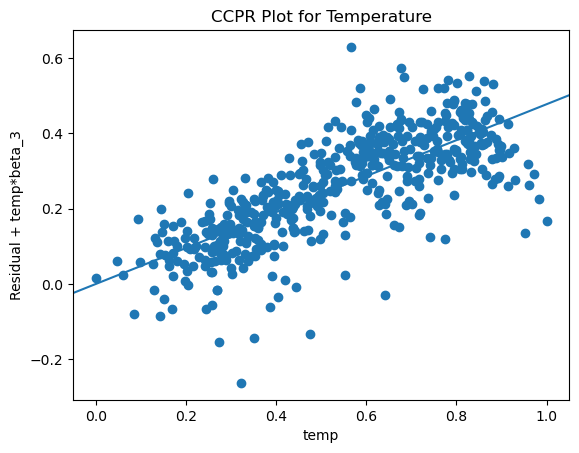

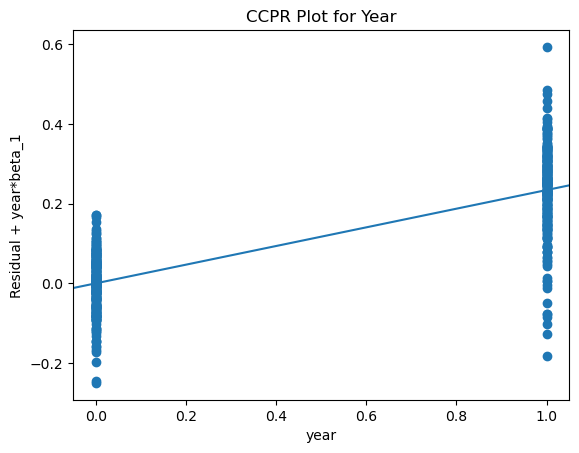

In [54]:
# Linear relationship validation using CCPR plot (Component and Component Plus Residual plot)

sm.graphics.plot_ccpr(lr_6, 'windspeed')
plt.title('CCPR Plot for Windspeed')
plt.show()

sm.graphics.plot_ccpr(lr_6, 'temp')
plt.title('CCPR Plot for Temperature')
plt.show()

sm.graphics.plot_ccpr(lr_6, 'year')
plt.title('CCPR Plot for Year')
plt.show()

The above visualizations clearly demonstrate the presence of linearity.

Multi Colinearity

In [55]:
calculateVIF(X_train_updated)

,Features,VIF
3,windspeed,4.60
2,temp,3.84
0,year,2.07
4,season_Spring,1.99
5,season_Summer,1.90
6,season_Winter,1.63
9,weathersit_Misty,1.55
7,month_Sep,1.23
8,weathersit_Light_snowshowers,1.08
1,holiday,1.04


The VIF values are below 5, indicating no issues with multicollinearity, which is further confirmed by the heatmap analysis.

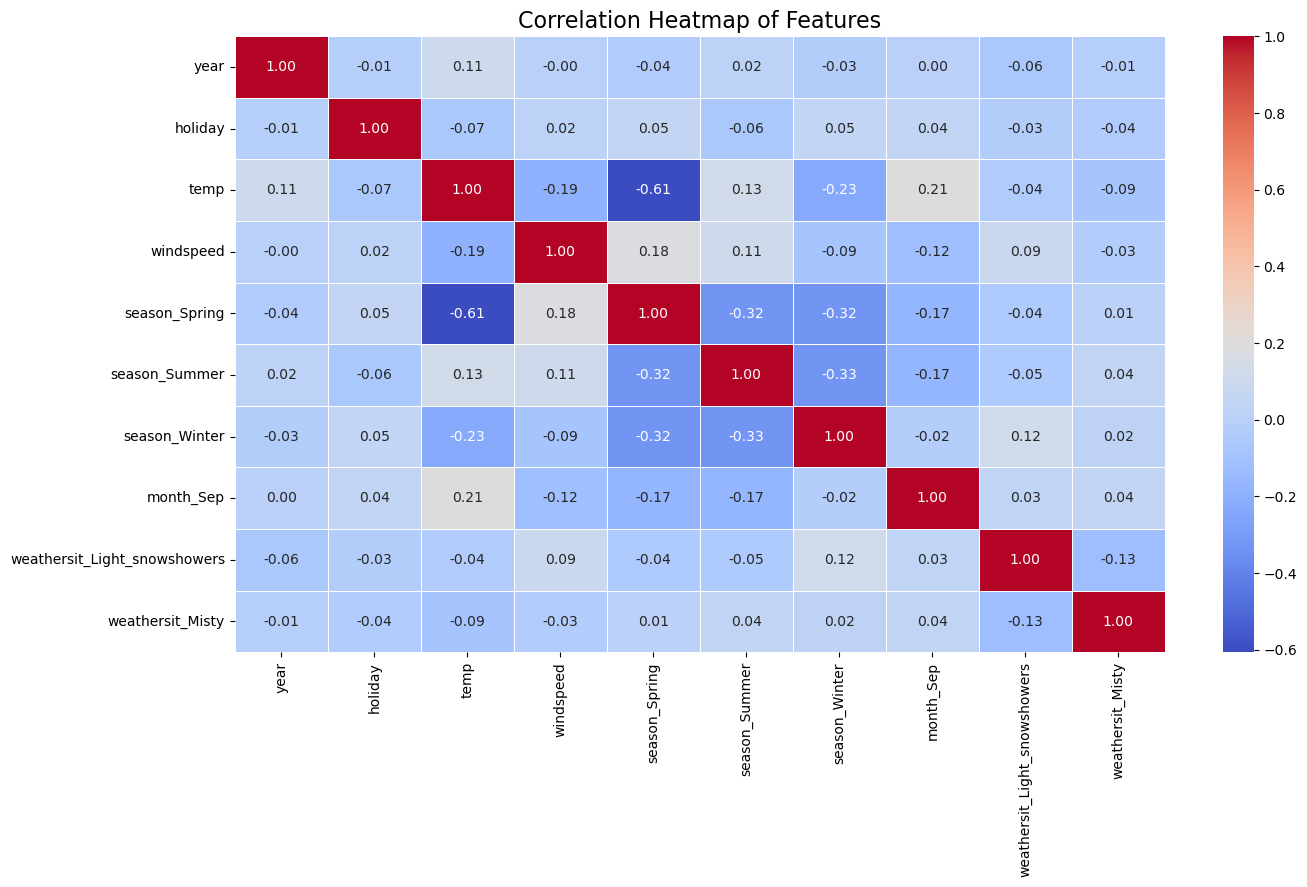

In [56]:
plt.figure(figsize=(15,8))
sns.heatmap(X_train_updated.corr(), annot=True, cmap="coolwarm", linewidths=0.5, fmt='.2f')
plt.title('Correlation Heatmap of Features', fontsize=16)
plt.show()

## Step 7: Making Predictions on the Final Model 

Having fitted the model and verified the normality of the error terms, we can now proceed to make predictions using the final model.

In [57]:
# Applying scaling on the test dataset
numerical_variables = ['temp', 'atemp', 'humidity', 'windspeed', 'cnt']
df1_test[numerical_variables] = scaler.transform(df1_test[numerical_variables])

In [58]:
df1_test.head()

,year,holiday,workingday,temp,atemp,humidity,windspeed,cnt,season_Spring,season_Summer,...,month_Oct,month_Sep,weekday_Mon,weekday_Sat,weekday_Sun,weekday_Thu,weekday_Tue,weekday_Wed,weathersit_Light_snowshowers,weathersit_Misty
184,0,1,0,0.831783,0.769660,0.657364,0.084219,0.692706,0,0,...,0,0,0,0,0,0,0,1,0,1
535,1,0,1,0.901354,0.842587,0.610133,0.153728,0.712034,0,1,...,0,0,0,0,0,1,0,0,0,0
299,0,0,0,0.511964,0.496145,0.837699,0.334206,0.303382,0,0,...,1,0,0,1,0,0,0,0,0,1
221,0,0,1,0.881625,0.795343,0.437098,0.339570,0.547400,0,0,...,0,0,0,0,0,0,0,0,0,0
152,0,0,0,0.817246,0.741471,0.314298,0.537414,0.569029,0,1,...,0,0,0,1,0,0,0,0,0,0


In [59]:
y_test = df1_test.pop('cnt')
X_test = df1_test

In [60]:
# Selecting the same columns from the test dataset as in the training set
col1 = X_train_updated.columns
X_test = X_test[col1]

X_test_lm_6 = sm.add_constant(X_test)
X_test_lm_6.head()

,const,year,holiday,temp,windspeed,season_Spring,season_Summer,season_Winter,month_Sep,weathersit_Light_snowshowers,weathersit_Misty
184,1.0,0,1,0.831783,0.084219,0,0,0,0,0,1
535,1.0,1,0,0.901354,0.153728,0,1,0,0,0,0
299,1.0,0,0,0.511964,0.334206,0,0,1,0,0,1
221,1.0,0,0,0.881625,0.339570,0,0,0,0,0,0
152,1.0,0,0,0.817246,0.537414,0,1,0,0,0,0


In [61]:
y_pred = lr_6.predict(X_test_lm_6)

**Understanding R-squared**  
R-squared is a statistical measure that evaluates how well a linear regression model fits the data. It represents the proportion of the variance in the dependent variable that is collectively explained by the independent variables. Expressed as a percentage, R-squared quantifies the strength of the relationship between the model and the dependent variable, ranging from 0% to 100%.

In [62]:
from sklearn.metrics import r2_score
# Predicting the values using the trained model
y_pred = lr_6.predict(X_test_lm_6)

r2 = r2_score(y_test, y_pred)

round(r2, 4)

0.8038

## Step 8: Model Evaluation

Let's now plot the graph for actual versus predicted values.

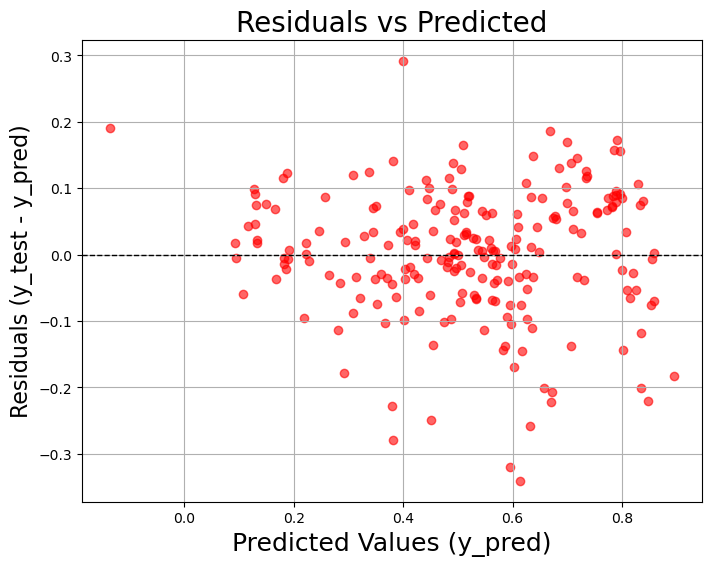

In [63]:
# Calculating residuals
residuals = y_test - y_pred

# Plotting residuals vs predicted values
plt.figure(figsize=(8, 6))
plt.scatter(y_pred, residuals, color='red', alpha=0.6)
plt.axhline(y=0, color='black', linestyle='--', linewidth=1)
plt.title('Residuals vs Predicted', fontsize=20)
plt.xlabel('Predicted Values (y_pred)', fontsize=18)
plt.ylabel('Residuals (y_test - y_pred)', fontsize=16)
plt.grid(True)
plt.show()


### Insights:  
The final model demonstrates a reliable fit and possesses reasonable predictive accuracy, indicating that the results are not due to random chance.

In [64]:
param = pd.DataFrame({
    'Variables': lr_6.params.index,
    'Coefficient Value': lr_6.params.values
}).reset_index(drop=True)

param = param.sort_values(by='Coefficient Value', ascending=False).reset_index(drop=True)

param

,Variables,Coefficient Value
0,temp,0.477737
1,year,0.234132
2,const,0.190855
3,season_Winter,0.094476
4,month_Sep,0.090998
5,season_Summer,0.062076
6,season_Spring,-0.055406
7,weathersit_Misty,-0.078741
8,holiday,-0.096316
9,windspeed,-0.148098


To express the linear regression model with the given coefficients in the best-fitted equation form, we can substitute the coefficients into the linear regression equation:  

Substituting the values from the table:

Bike Demand (cnt)=0.1909+0.4777⋅temp+0.2341⋅year+0.0945⋅season_Winter+0.0910⋅month_Sep+0.0621⋅season_Summer−0.0554⋅season_Spring−0.0787⋅weathersit_Misty−0.0963⋅holiday−0.1481⋅windspeed−0.2850⋅weathersit_Light_snowshowers

### Explanation:
1. **Constant**: 0.1909  
2. **Predictor Variable**:
   - The variables like `temp`, `year`, `windspeed`, and categorical variables (`season_Winter`, `month_Sep`, etc.) represent their respective features.  
3. **Coefficients**: 
   - Positive coefficients (e.g., `temp` with 0.4777) indicate a positive relationship with bike demand.
   - Negative coefficients (e.g., `weathersit_Light_snowshowers` with -0.2850) indicate an inverse relationship.  

This equation can now be used to predict `cnt` (bike demand) for a given set of inputs.

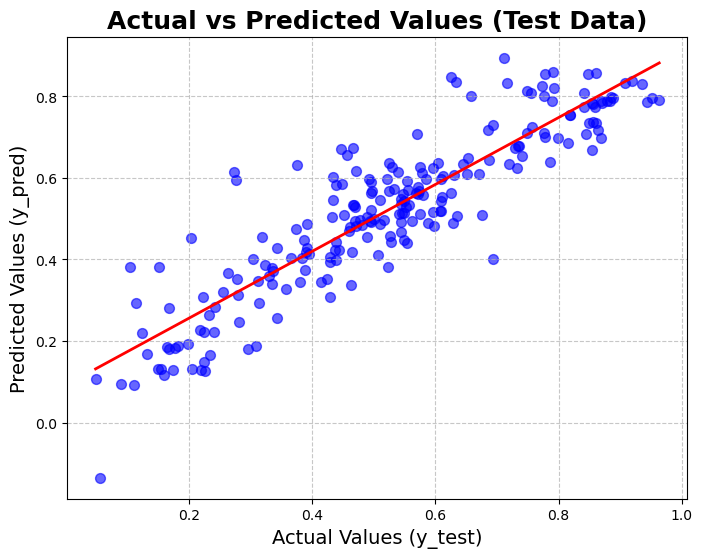

In [65]:
# Visualizing the fit on the test data using a regression plot
plt.figure(figsize=(8, 6))
sns.regplot(
    x=y_test, 
    y=y_pred, 
    ci=None,
    fit_reg=True,
    scatter_kws={"color": "blue", "alpha": 0.6, "s": 50},
    line_kws={"color": "red", "linewidth": 2}
)
plt.title('Actual vs Predicted Values (Test Data)', fontsize=18, weight='bold')
plt.xlabel('Actual Values (y_test)', fontsize=14)
plt.ylabel('Predicted Values (y_pred)', fontsize=14)
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [66]:
def adjusted_r2(r2, n, k):
    """
    r2: R-squared value
    n: Number of observations
    k: Number of predictors
    """
    return round(1 - (1 - r2) * (n - 1) / (n - k - 1), 4)

y_train_pred = lr_6.predict(sm.add_constant(X_train_updated))  
r2_train = r2_score(y_train, y_train_pred) 

r2_test = r2_score(y_test, y_pred) 

n_train, k_train = X_train_updated.shape
adj_r2_train = adjusted_r2(r2_train, n_train, k_train)

n_test, k_test = X_test.shape
adj_r2_test = adjusted_r2(r2_test, n_test, k_test)

print(f"Train dataset R^2: {round(r2_train, 4)}")
print(f"Test dataset R^2: {round(r2_test, 4)}")
print(f"Train dataset Adjusted R^2: {adj_r2_train}")
print(f"Test dataset Adjusted R^2: {adj_r2_test}")

Train dataset R^2: 0.8327
Test dataset R^2: 0.8038
Train dataset Adjusted R^2: 0.8294
Test dataset Adjusted R^2: 0.7944


**Analysis and Interpretation of Bike Demand Model:**

1. **Coefficient Analysis:**
   - **Positive Coefficients:** 
     - Variables such as **Temperature**, **Season_Summer**, **Year**, and **Season_Winter** have positive coefficients, indicating that an increase in these factors will lead to a higher **bike demand (cnt)**.
   - **Negative Coefficients:**
     - On the other hand, **Wind Speed**, **Holiday**, **Weathersit_Misty**, and **Weathersit_Light_snowshowers** show negative coefficients. This suggests that an increase in these factors will result in a decrease in the bike demand.

2. **Model Performance:**
   - The **R-squared** and **Adjusted R-squared** values for both the training and test datasets suggest that the model explains over **81%** of the variance in bike demand. This signifies a strong relationship between the model and the target variable.

3. **Key Features Influencing Bike Demand:**
   - **Temperature (0.477737):** Temperature has the highest positive coefficient, suggesting that warmer weather leads to higher bike demand.
   - **Weathersit (Light Snow, Light Rain + Mist & Cloudy) (-0.285031):** Adverse weather conditions like light snow and rain reduce demand.
   - **Year (0.234132):** A slight increase in the year value correlates with an increase in bike demand.

4. **Conclusions:**
   - **Temperature**, **Season/Weather**, and **Month** are the most influential variables in predicting bike demand.
   - **Months with higher demand:** January, July, September, November, and December show a higher bike demand, which the company should focus on.
   - **Weather's Impact:** A rise in temperature corresponds to an increase in demand, and colder weather, especially during winter, sees a demand spike. Conversely, adverse weather (like snow or mist) reduces demand.
   - **Holiday Impact:** The demand during holidays is lower, suggesting a need for marketing strategies or incentives to boost interest.

5. **Final Recommendations for the Company:**
   - **Focus on High Demand Months:** The company should prioritize operational strategies during months with higher demand, such as January, July, September, November, and December.
   - **Monitor Weather Conditions:** Keep track of temperature and seasonal changes, as higher temperatures significantly boost demand. Prepare for winter, which sees increased bike usage.
   - **Holiday Strategy:** Given the lower demand during holidays, marketing efforts or incentives can encourage more biking during these periods.